In [24]:
!pip install pandas matplotlib seaborn numpy

In [25]:
import pandas as pd
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pasta_principal = str(Path().resolve().parent)
if pasta_principal not in sys.path:
    sys.path.append(pasta_principal)

# 2. Importa as suas funções personalizadas em português
from src.data_loader import carregar_dados_brutos
from src.eda import resumir_valores_ausentes, identificar_outliers_iqr
from src.preprocessing import corrigir_valores_invalidos
from src.visualization import obter_pasta_de_graficos


In [26]:
data = carregar_dados_brutos('../data/raw/college_sleep_and_gpa.csv')

print("Começo do DataSet:")
display(data.head(5))

print("Fim do DataSet:")
display(data.tail(5))

print("Dimensão do DataSet:")
display(data.shape)

Começo do DataSet:


,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54


Fim do DataSet:


,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
629,347,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,445.6,7.43,...,0.0950,1.000,3.74,3.74,0.00,46.0,-0.663,0,7-7.5h,04:13
630,349,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,430.8,7.18,...,0.1070,0.276,3.44,3.61,0.17,49.0,-0.139,0,7-7.5h,04:51
631,353,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,360.9,6.01,...,0.0608,1.000,3.62,3.81,0.19,54.0,0.735,0,6-6.5h,06:33
632,356,5,Carnegie Mellon University,Spring 2017,lac1,Male,0.0,0.0,303.8,5.06,...,0.1568,0.276,3.22,1.38,-1.84,48.0,-0.313,1,<5.5h,06:11
633,357,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,397.9,6.63,...,0.2347,0.897,4.00,4.00,0.00,49.0,-0.139,0,6.5-7h,05:48


Dimensão do DataSet:


(634, 22)

In [27]:
print("Informações do DataSet:")
data.info()

Informações do DataSet:
<class 'pandas.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               634 non-null    int64  
 1   study                    634 non-null    int64  
 2   university               634 non-null    str    
 3   semester                 634 non-null    str    
 4   cohort_code              634 non-null    str    
 5   gender                   631 non-null    str    
 6   first_generation         630 non-null    float64
 7   underrepresented         633 non-null    float64
 8   avg_sleep_minutes        634 non-null    float64
 9   avg_sleep_hours          634 non-null    float64
 10  daytime_sleep_minutes    634 non-null    float64
 11  sleep_midpoint_minutes   634 non-null    float64
 12  bedtime_variability      634 non-null    float64
 13  nights_tracked_fraction  634 non-null    float64
 14  prior_gpa    

In [28]:
display(data.describe())
display(data.describe(include='str'))
display(data.describe(include='number'))

,student_id,study,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep
count,634.000000,634.000000,630.000000,633.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,487.000000,487.000000,634.000000
mean,13005.892744,3.181388,0.166667,0.187994,397.324763,6.622098,41.165615,398.678707,0.451687,0.867478,3.465584,3.449587,-0.015997,29.392197,-0.000057,0.208202
std,26496.593477,1.317125,0.377213,0.391016,50.855641,0.847741,27.388294,72.712017,1.393631,0.178999,0.437578,0.500463,0.403109,17.642780,1.000017,0.406343
min,1.000000,1.000000,0.000000,0.000000,194.800000,3.250000,2.300000,247.100000,0.004500,0.214000,1.210000,0.350000,-1.877000,5.000000,-3.983000,0.000000
25%,178.000000,2.000000,0.000000,0.000000,366.950000,6.112500,23.100000,345.175000,0.074700,0.821000,3.232250,3.233000,-0.189500,15.000000,-0.551000,0.000000
50%,358.500000,3.000000,0.000000,0.000000,400.350000,6.675000,35.000000,388.250000,0.135000,0.932000,3.558000,3.556000,0.000000,17.000000,0.041000,0.000000
75%,592.750000,4.000000,0.000000,0.000000,430.100000,7.170000,51.250000,437.625000,0.291700,1.000000,3.789500,3.810000,0.193750,48.000000,0.560000,0.000000
max,99978.000000,5.000000,2.000000,1.000000,587.700000,9.790000,292.300000,724.700000,20.849200,1.000000,4.000000,4.000000,1.332000,73.000000,4.055000,1.000000


,university,semester,cohort_code,gender,sleep_bracket,sleep_midpoint_clock
count,634,634,634,631,634,634
unique,3,4,5,2,6,238
top,University of Washington,Spring 2018,nh,Female,6.5-7h,05:48
freq,279,217,147,368,172,9


,student_id,study,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep
count,634.000000,634.000000,630.000000,633.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,487.000000,487.000000,634.000000
mean,13005.892744,3.181388,0.166667,0.187994,397.324763,6.622098,41.165615,398.678707,0.451687,0.867478,3.465584,3.449587,-0.015997,29.392197,-0.000057,0.208202
std,26496.593477,1.317125,0.377213,0.391016,50.855641,0.847741,27.388294,72.712017,1.393631,0.178999,0.437578,0.500463,0.403109,17.642780,1.000017,0.406343
min,1.000000,1.000000,0.000000,0.000000,194.800000,3.250000,2.300000,247.100000,0.004500,0.214000,1.210000,0.350000,-1.877000,5.000000,-3.983000,0.000000
25%,178.000000,2.000000,0.000000,0.000000,366.950000,6.112500,23.100000,345.175000,0.074700,0.821000,3.232250,3.233000,-0.189500,15.000000,-0.551000,0.000000
50%,358.500000,3.000000,0.000000,0.000000,400.350000,6.675000,35.000000,388.250000,0.135000,0.932000,3.558000,3.556000,0.000000,17.000000,0.041000,0.000000
75%,592.750000,4.000000,0.000000,0.000000,430.100000,7.170000,51.250000,437.625000,0.291700,1.000000,3.789500,3.810000,0.193750,48.000000,0.560000,0.000000
max,99978.000000,5.000000,2.000000,1.000000,587.700000,9.790000,292.300000,724.700000,20.849200,1.000000,4.000000,4.000000,1.332000,73.000000,4.055000,1.000000


In [29]:
invalidos = data[~data['first_generation'].isin([0, 1]) & data['first_generation'].notna()]['first_generation']

if not invalidos.empty:
    for val in invalidos.unique():
        print(f"Valor inválido encontrado na coluna 'first_generation': {val}")
    
    data = corrigir_valores_invalidos(data)
    print("O valor 2 foi substituído por 1 com sucesso.")

Valor inválido encontrado na coluna 'first_generation': 2.0
O valor 2 foi substituído por 1 com sucesso.


In [30]:

print("Quantidades de valores nulos por coluna:")
resumo_nulos = resumir_valores_ausentes(data)
nulos = resumo_nulos['Valores Ausentes']
display(nulos)

nulos_percentual = resumo_nulos['Porcentagem (%)']
print("Percentual de valores nulos por coluna:")
display(nulos_percentual[nulos_percentual > 0])

Quantidades de valores nulos por coluna:


term_load_z         147
term_units          147
first_generation      4
gender                3
underrepresented      1
Name: Valores Ausentes, dtype: int64

Percentual de valores nulos por coluna:


term_load_z         23.186120
term_units          23.186120
first_generation     0.630915
gender               0.473186
underrepresented     0.157729
Name: Porcentagem (%), dtype: float64

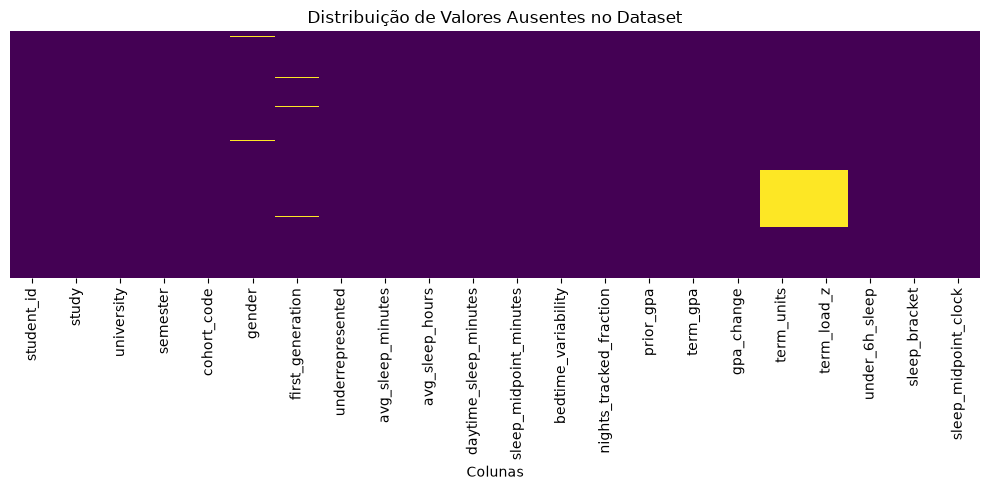

In [31]:
plt.figure(figsize=(10, 5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Distribuição de Valores Ausentes no Dataset')
plt.xlabel('Colunas')
plt.tight_layout()
plt.savefig(obter_pasta_de_graficos() / 'distribuicao_nulos.png', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_21183/2972749834.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos.index, y=nulos.values, palette='magma')


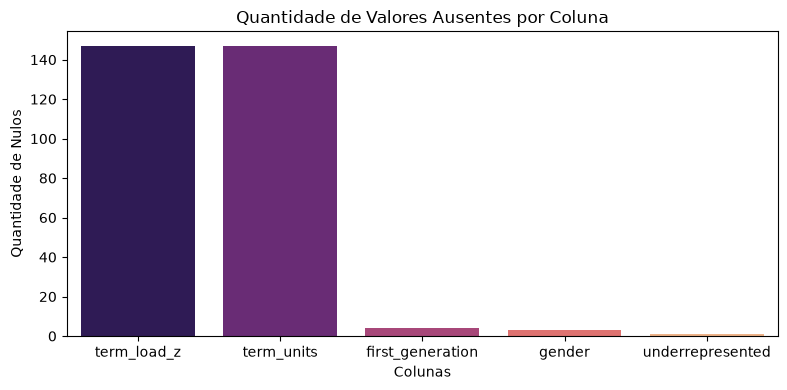

In [32]:
plt.figure(figsize=(8, 4))
sns.barplot(x=nulos.index, y=nulos.values, palette='magma')
plt.title('Quantidade de Valores Ausentes por Coluna')
plt.ylabel('Quantidade de Nulos')
plt.xlabel('Colunas')
plt.tight_layout()
plt.savefig(obter_pasta_de_graficos() / 'quantidade_valores_ausentes.png', bbox_inches='tight', dpi=300)
plt.show()

In [33]:
colOut = [
    'avg_sleep_hours',
    'daytime_sleep_minutes',
    'sleep_midpoint_minutes',
    'bedtime_variability',
    'prior_gpa',
    'term_gpa',
    'gpa_change',
    'term_load_z'
]

outliers_iqr = identificar_outliers_iqr(data, colOut)

for col in colOut:
    print(f"{col}: {len(outliers_iqr[col])} outliers encontrados.")

avg_sleep_hours: 11 outliers encontrados.
daytime_sleep_minutes: 29 outliers encontrados.
sleep_midpoint_minutes: 15 outliers encontrados.
bedtime_variability: 94 outliers encontrados.
prior_gpa: 17 outliers encontrados.
term_gpa: 21 outliers encontrados.
gpa_change: 43 outliers encontrados.
term_load_z: 11 outliers encontrados.


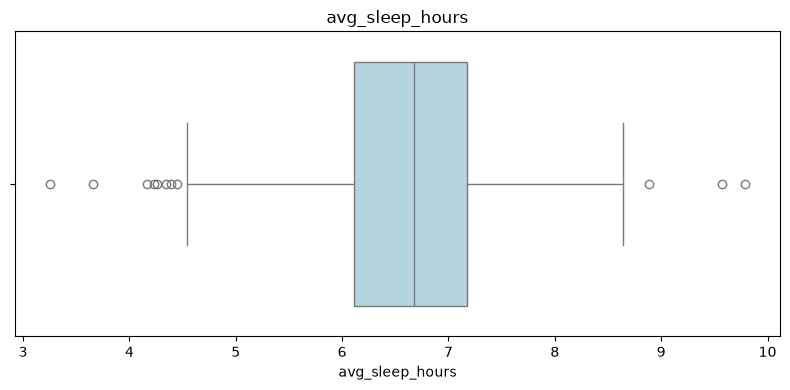

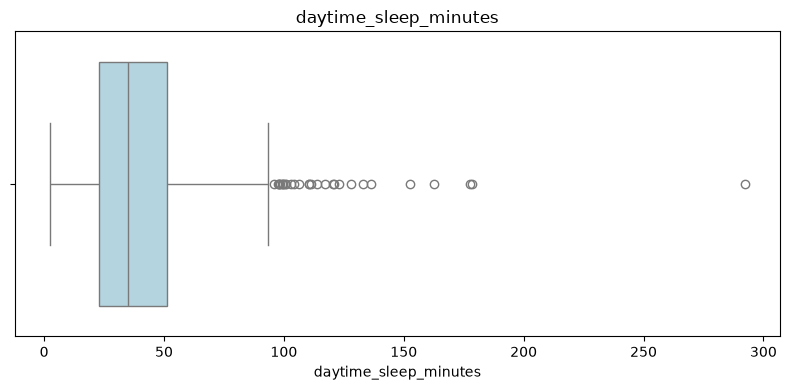

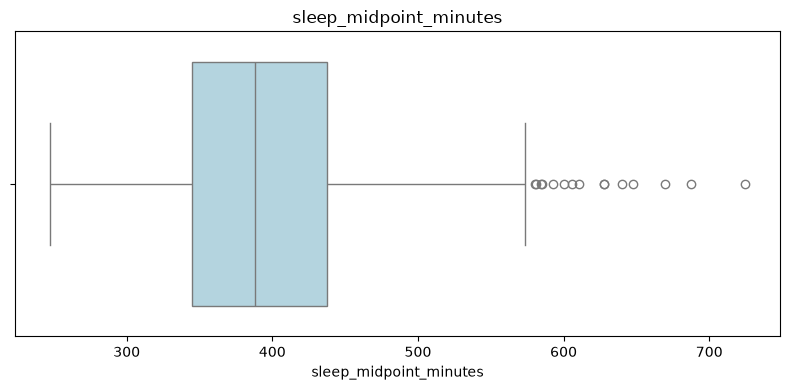

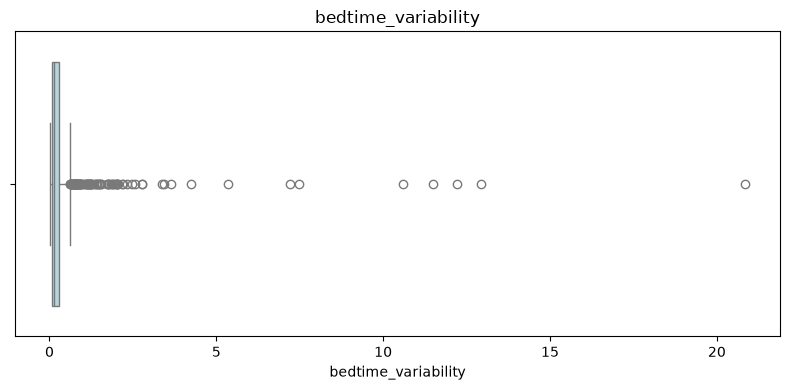

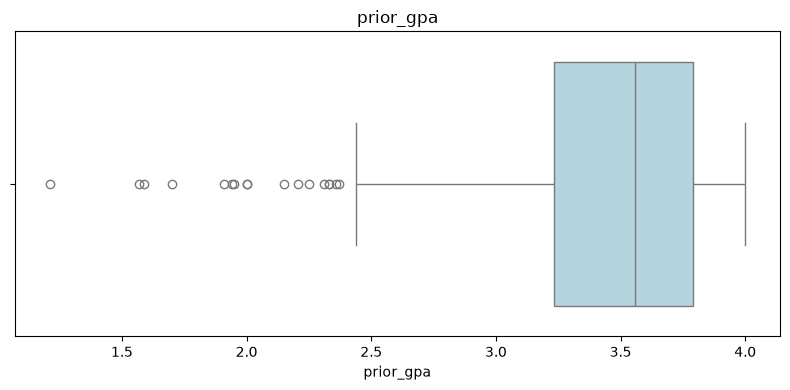

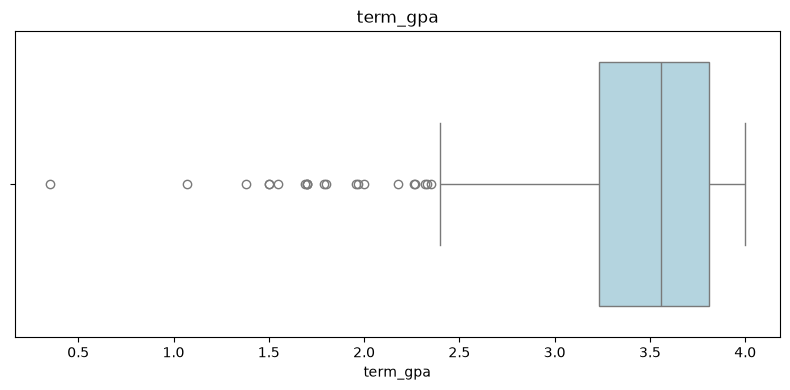

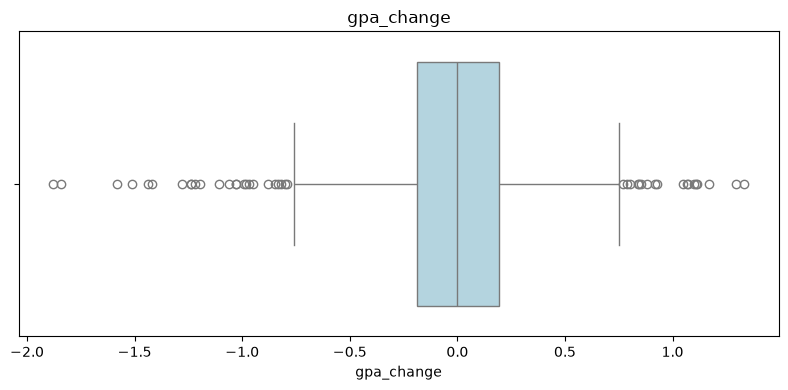

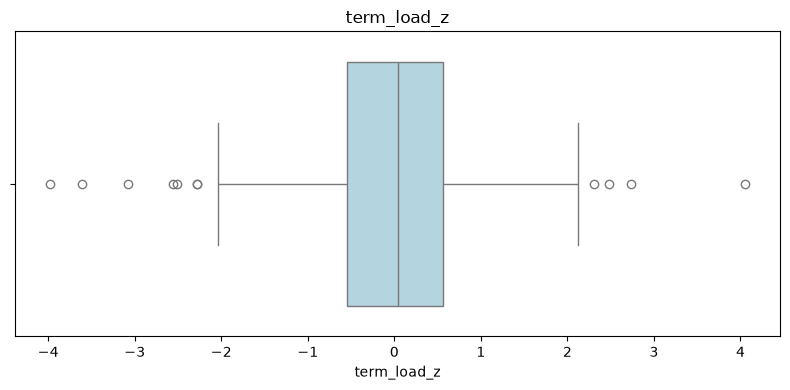

In [34]:
pasta_graficos = obter_pasta_de_graficos()

for col in colOut:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col], color='lightblue')
    plt.title(col)
    plt.xlabel(col)
    plt.tight_layout()
    
    plt.savefig(pasta_graficos / f'boxplot_{col}.png', bbox_inches='tight', dpi=300)
    
    plt.show()

In [35]:
for col in colOut:
    media = data[col].mean()
    desvio = data[col].std()
    
    z_scores = (data[col] - media) / desvio
    
    outliers = data[np.abs(z_scores) > 3]
    
    print(f"=== Coluna: {col} ===")
    print(f"Média: {media:.2f} | Desvio Padrão: {desvio:.2f}")
    print(f"Outliers detectados (|Z| > 3): {len(outliers)}")
    print("-" * 40)

=== Coluna: avg_sleep_hours ===
Média: 6.62 | Desvio Padrão: 0.85
Outliers detectados (|Z| > 3): 4
----------------------------------------
=== Coluna: daytime_sleep_minutes ===
Média: 41.17 | Desvio Padrão: 27.39
Outliers detectados (|Z| > 3): 8
----------------------------------------
=== Coluna: sleep_midpoint_minutes ===
Média: 398.68 | Desvio Padrão: 72.71
Outliers detectados (|Z| > 3): 7
----------------------------------------
=== Coluna: bedtime_variability ===
Média: 0.45 | Desvio Padrão: 1.39
Outliers detectados (|Z| > 3): 8
----------------------------------------
=== Coluna: prior_gpa ===
Média: 3.47 | Desvio Padrão: 0.44
Outliers detectados (|Z| > 3): 10
----------------------------------------
=== Coluna: term_gpa ===
Média: 3.45 | Desvio Padrão: 0.50
Outliers detectados (|Z| > 3): 12
----------------------------------------
=== Coluna: gpa_change ===
Média: -0.02 | Desvio Padrão: 0.40
Outliers detectados (|Z| > 3): 11
----------------------------------------
=== Coluna: 